1.data(prepare and load)
2.build model
3.fitting the model to data(training)
4.making predictions and evaluting a model(inference)
5.saving and loading a model
6.putting it all together

In [1]:
import torch
from torch import nn     #contain all of the building blocks for neural networks
import matplotlib.pyplot as plt


Data prepare and load (80% training 10+10% validation  20%test)

In [2]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

# Create train/test split
train_split = int(0.8 * len(X)) # 80% of data used for training set, 20% for testing 
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


Build the model



For each model you build, you need to define the forward method by yourself

In [3]:
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

In [4]:
if torch.cuda.is_available():
    devices = "cuda" 
elif torch.backends.mps.is_available():
    devices = "mps" 
else:
    devices = "cpu" 

create the model on the GPU (if applicable)

In [5]:

model_0 = LinearRegressionModel()#.to(device=devices) #create the model

Check the parameters in the model

In [6]:
print(model_0.state_dict())

OrderedDict({'weights': tensor([0.1439]), 'bias': tensor([0.1145])})


Set the Loss Function (cost function)

In [7]:
loss_fn = nn.MSELoss()

Choose the optimizer
(the optimizer will update the parameters for your model)
it recivces the parameters(with gradient) you want to optimize, 
and also the learning rate you want to apply to the gradient descent

In [8]:
optimizer = torch.optim.Adam(params=model_0.parameters(),lr=0.1)

Train and Test

Train:

Put model in training mode (this is the default state of a model)

1. Forward pass on train data using the forward() method inside 

2. Calculate the loss (how different are our models predictions to the ground truth)

3. Zero grad of the optimizer

4. Loss backwards

5. Progress the optimizer



Test:

Put the model in evaluation mode

1. Forward pass on test data

2. Caculate loss on test data

3. Evaluation


In [9]:
# Set the number of epochs (how many times the model will pass over the training data)
epochs = 100

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.17837513983249664 | MAE Test Loss: 0.24218972027301788 
Epoch: 10 | MAE Train Loss: 0.014828644692897797 | MAE Test Loss: 0.00011208847718080506 
Epoch: 20 | MAE Train Loss: 0.004461423493921757 | MAE Test Loss: 0.007087497506290674 
Epoch: 30 | MAE Train Loss: 0.001013259869068861 | MAE Test Loss: 3.9524697058368474e-05 
Epoch: 40 | MAE Train Loss: 8.291702397400513e-05 | MAE Test Loss: 0.00022949415142647922 
Epoch: 50 | MAE Train Loss: 6.894965190440416e-05 | MAE Test Loss: 5.462685294332914e-05 
Epoch: 60 | MAE Train Loss: 0.00014001135423313826 | MAE Test Loss: 0.0005391115555539727 
Epoch: 70 | MAE Train Loss: 7.014607399469241e-05 | MAE Test Loss: 6.952828698558733e-05 
Epoch: 80 | MAE Train Loss: 4.502841420617187e-06 | MAE Test Loss: 3.3869885101012187e-06 
Epoch: 90 | MAE Train Loss: 4.727297437057132e-06 | MAE Test Loss: 4.741435077448841e-06 


Make inference


In [10]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
print(y_preds)

tensor([[0.8575],
        [0.8714],
        [0.8854],
        [0.8994],
        [0.9133],
        [0.9273],
        [0.9412],
        [0.9552],
        [0.9691],
        [0.9831]])


Saving a model
There are two ways to save the model:
1. save the state_dict()   commonly using .pth

2. save the model() commonly using .pt

In [11]:
model_save_path_0 = 'D:\codes\code_xjtu\pytorch\study\computer_vision\saved_model\model_0.state_dict.pth'
model_save_path_1 = 'D:\codes\code_xjtu\pytorch\study\computer_vision\saved_model\model_0.pt'


torch.save(obj=model_0.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=model_save_path_0)
torch.save(obj=model_0,f=model_save_path_1)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\chuyi\AppData\Local\Temp\ipykernel_28676\1245922199.py:1: SyntaxWarning: invalid escape sequence '\c'
  model_save_path_0 = 'D:\codes\code_xjtu\pytorch\study\computer_vision\saved_model\model_0.state_dict.pth'
C:\Users\chuyi\AppData\Local\Temp\ipykernel_28676\1245922199.py:2: SyntaxWarning: invalid escape sequence '\c'
  model_save_path_1 = 'D:\codes\code_xjtu\pytorch\study\computer_vision\saved_model\model_0.pt'


Load the model from file

In [12]:
# Instantiate a new instance of our model (this will be instantiated with random weights)
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model (this will update the new instance of our model with trained weights)
loaded_model_0.load_state_dict(torch.load(f=model_save_path_0,weights_only=True))

# Load with file saving the entire model

# Model class must be defined somewhere
loaded_model_1 = torch.load(model_save_path_1,weights_only=False)


Building a linear model

In [13]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import numpy as np
import matplotlib.pyplot as plt
import json
import torch
from torch import nn
from pprint import pprint


Prepare the data

LinearRegressionModelV2(
  (linaer_layer): Linear(in_features=1, out_features=1, bias=True)
) 

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\chuyi\AppData\Local\Temp\ipykernel_28676\2486278627.py:1: SyntaxWarning: invalid escape sequence '\c'
  datapath = 'D:\codes\code_xjtu\\basic_module\housing.data'


OrderedDict({'linaer_layer.weight': tensor([[0.5125]], device='cuda:0'), 'linaer_layer.bias': tensor([0.6111], device='cuda:0')})
tensor([[15.6672],
        [17.2132],
        [ 1.4992],
        [16.4504],
        [16.5419],
        [29.1029],
        [17.9658],
        [27.1196],
        [ 6.4829],
        [11.8430],
        [ 5.3743],
        [24.8515],
        [28.3910],
        [13.3584],
        [20.0000],
        [28.8181],
        [24.6176],
        [20.4984],
        [16.8572],
        [21.4849],
        [16.0130],
        [19.3796],
        [18.7795],
        [22.4919],
        [22.4003],
        [24.3023],
        [23.9768],
        [28.9097],
        [24.7600],
        [24.8718],
        [22.5529],
        [26.8348],
        [25.1261],
        [21.9833],
        [19.7762],
        [16.6436],
        [18.5863],
        [24.5667],
        [22.6648],
        [25.3702],
        [18.9524],
        [25.1058],
        [23.9056],
        [22.9902],
        [22.3190],
        [24.678

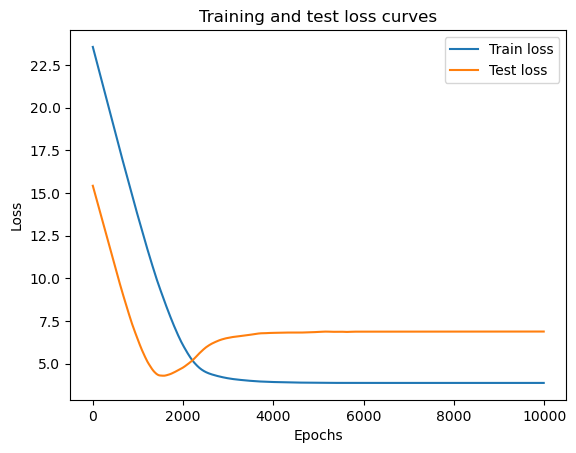

In [14]:
datapath = 'D:\codes\code_xjtu\\basic_module\housing.data'

database = np.fromfile(datapath,sep=' ',dtype=np.float32)

feature_names = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE',
                    'DIS','RAD','TAX','PTRATIO','B','LSTAT','MEDV']
feature_num = len(feature_names)

#reshape the data as single sample
data = database.reshape([database.shape[0]//feature_num, feature_num])

x = data[:,5]
y = data[:,13]

x_max, x_min = x.max(), x.min()
mean = x.mean()
x = (x - mean) / (x_max - x_min)

devices
if(torch.cuda.is_available()):
    devices = "cuda"
elif(torch.backends.mps.is_available()):
    devices = 'mps'
else:
    devices = 'cpu'

split = int(len(x)*0.8)
x_train = torch.tensor(x[:split],device=devices).unsqueeze(1)
y_train = torch.tensor(y[:split],device=devices).unsqueeze(1)
x_test = torch.tensor(x[split:],device=devices).unsqueeze(1)
y_test = torch.tensor(y[split:],device=devices).unsqueeze(1)


class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linaer_layer = nn.Linear(in_features=1,out_features=1,bias=True)

    def forward(self,x:torch.Tensor) -> torch.Tensor:
        return self.linaer_layer(x)
    

model_1 = LinearRegressionModelV2().to(devices)
print(model_1,model_1.state_dict())

loss_fn = nn.L1Loss()

optimizer = torch.optim.Adam(params=model_1.parameters(),lr=0.01)

epochs = 10000

train_loss_values = []
test_loss_values = []
epoch_count = []



for epoch in range(epochs):
    model_1.train()

    y_train_pred = model_1(x_train)

    loss_train = loss_fn(y_train_pred,y_train)

    optimizer.zero_grad()

    loss_train.backward()

    optimizer.step()

    model_1.eval()

    with torch.inference_mode() :
        y_test_pred = model_1(x_test)

        loss_test = loss_fn(y_test_pred,y_test)
    
    if epoch % 10 == 0 :

        train_loss_values.append(loss_train.detach().cpu().numpy())
        test_loss_values.append(loss_test.detach().cpu().numpy())
        epoch_count.append(epoch)


model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(x_test)
    pprint(y_preds)



plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()
